# NIFTY50 Alpha#1: Research to Alpha

This is the single working notebook for the Alpha#1 workflow. It uses real NIFTY50-style market data from Yahoo Finance via `yfinance`; there is no synthetic data path.

The notebook is designed to answer the question in stages: do we have clean data, does the raw formula point the right way, does the oriented signal have predictive information, do buckets/backtests show useful behavior after costs, does parameter selection survive walk-forward testing, and what would the current alpha candidate list look like?

## Workflow Map

1. **Load market data**: current NIFTY50-style symbols plus `^NSEI`, cached locally after download.
2. **Validate data**: missing fields, OHLC consistency, suspicious adjusted returns, usable symbols.
3. **Compute Alpha#1**: the original cross-sectional formula.
4. **Orient the signal**: measure whether raw Alpha#1 is bullish or inverted on forward returns.
5. **Diagnose signal quality**: Rank IC, bucket spread, stability through time.
6. **Backtest simple baskets**: long-only and long/short diagnostics after turnover costs.
7. **Search alpha rules**: thresholds, holding count, rebalance cadence, regime gates.
8. **Walk-forward test**: choose orientation and params on training windows, score only later windows.
9. **Emit final candidate table**: latest names, weights, scores, and reason codes.

In [1]:
from __future__ import annotations

import itertools
import math
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
pd.options.display.float_format = "{:.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError("Run `.venv/bin/python -m pip install -r requirements.txt` first.") from exc

START_DATE = "2018-01-01"
END_DATE = None
DEFAULT_HORIZON = 5
FORWARD_HORIZONS = [1, 3, 5, 10]
TOP_N_VALUES = [5, 10]
ANNUALIZATION = 252
COST_BPS_PER_TURNOVER = 10.0
REFRESH_DATA = False

DATA_DIR = Path("research/data/alpha001_nifty50")
ARTIFACT_DIR = Path("research/artifacts/alpha001_research_to_alpha")
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

NIFTY50_SYMBOLS = [
    "ADANIENT", "ADANIPORTS", "APOLLOHOSP", "ASIANPAINT", "AXISBANK",
    "BAJAJ-AUTO", "BAJFINANCE", "BAJAJFINSV", "BEL", "BHARTIARTL",
    "CIPLA", "COALINDIA", "DRREDDY", "EICHERMOT", "ETERNAL",
    "GRASIM", "HCLTECH", "HDFCBANK", "HDFCLIFE", "HINDALCO",
    "HINDUNILVR", "ICICIBANK", "INDIGO", "INFY", "ITC",
    "JIOFIN", "JSWSTEEL", "KOTAKBANK", "LT", "M&M",
    "MARUTI", "MAXHEALTH", "NESTLEIND", "NTPC", "ONGC",
    "POWERGRID", "RELIANCE", "SBILIFE", "SHRIRAMFIN", "SBIN",
    "SUNPHARMA", "TATACONSUM", "TATAMOTORS", "TATASTEEL", "TCS",
    "TECHM", "TITAN", "TRENT", "ULTRACEMCO", "WIPRO",
]
YF_TICKERS = [f"{symbol}.NS" for symbol in NIFTY50_SYMBOLS]
SYMBOL_FROM_TICKER = dict(zip(YF_TICKERS, NIFTY50_SYMBOLS))
NIFTY_INDEX_TICKER = "^NSEI"

print(f"Universe symbols configured: {len(NIFTY50_SYMBOLS)}")
print(f"Date range: {START_DATE} to latest available")
print(f"Cost assumption: {COST_BPS_PER_TURNOVER:.1f} bps per unit of turnover")

Universe symbols configured: 50
Date range: 2018-01-01 to latest available
Cost assumption: 10.0 bps per unit of turnover


## 1. Load Real Market Data

This cell downloads adjusted and raw OHLCV data from Yahoo Finance if local CSV caches are absent or `REFRESH_DATA=True`. Once cached, later runs reuse the local files so you can iterate quickly.

In [2]:
FIELD_FILES = {
    "open": DATA_DIR / "open.csv",
    "high": DATA_DIR / "high.csv",
    "low": DATA_DIR / "low.csv",
    "close": DATA_DIR / "close.csv",
    "adj_close": DATA_DIR / "adj_close.csv",
    "volume": DATA_DIR / "volume.csv",
    "nifty_close": DATA_DIR / "nifty_close.csv",
}


def read_frame(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, index_col=0, parse_dates=True)
    frame.index = pd.to_datetime(frame.index).tz_localize(None)
    return frame.sort_index()


def write_frame(frame: pd.DataFrame | pd.Series, path: Path) -> None:
    out = frame.to_frame() if isinstance(frame, pd.Series) else frame
    out.to_csv(path)


def extract_series(raw_data: pd.DataFrame, ticker: str, field: str) -> pd.Series | None:
    if raw_data.empty:
        return None
    if isinstance(raw_data.columns, pd.MultiIndex):
        candidates = [(ticker, field), (field, ticker)]
        for key in candidates:
            if key in raw_data.columns:
                return raw_data[key].astype(float)
        return None
    if field in raw_data.columns:
        return raw_data[field].astype(float)
    return None


def extract_field(raw_data: pd.DataFrame, field: str) -> pd.DataFrame:
    frames = {}
    for ticker in YF_TICKERS:
        series = extract_series(raw_data, ticker, field)
        if series is not None:
            frames[SYMBOL_FROM_TICKER[ticker]] = series
    frame = pd.DataFrame(frames).sort_index()
    frame.index = pd.to_datetime(frame.index).tz_localize(None)
    return frame.loc[~frame.index.duplicated(keep="last")]


def download_and_cache() -> dict[str, pd.DataFrame | pd.Series]:
    tickers = YF_TICKERS + [NIFTY_INDEX_TICKER]
    raw = yf.download(
        tickers=tickers,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        group_by="ticker",
        threads=True,
        progress=False,
    )
    if raw.empty:
        raise ValueError("No data downloaded from yfinance. Check network access and ticker availability.")

    data = {
        "open": extract_field(raw, "Open"),
        "high": extract_field(raw, "High"),
        "low": extract_field(raw, "Low"),
        "close": extract_field(raw, "Close"),
        "adj_close": extract_field(raw, "Adj Close"),
        "volume": extract_field(raw, "Volume"),
    }
    nifty_close = extract_series(raw, NIFTY_INDEX_TICKER, "Close")
    if nifty_close is None:
        nifty_raw = yf.download(NIFTY_INDEX_TICKER, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)
        nifty_close = extract_series(nifty_raw, NIFTY_INDEX_TICKER, "Close") or extract_series(nifty_raw, "Close", "Close")
    if nifty_close is None:
        raise ValueError("Could not extract NIFTY index close from yfinance output.")
    nifty_close.index = pd.to_datetime(nifty_close.index).tz_localize(None)
    data["nifty_close"] = nifty_close.rename("nifty_close").sort_index()

    for name, frame in data.items():
        write_frame(frame, FIELD_FILES[name])
    return data


def load_market_data() -> dict[str, pd.DataFrame | pd.Series]:
    cache_ready = all(path.exists() for path in FIELD_FILES.values())
    if cache_ready and not REFRESH_DATA:
        data = {name: read_frame(path) for name, path in FIELD_FILES.items()}
        data["nifty_close"] = data["nifty_close"].iloc[:, 0].rename("nifty_close")
        print("Loaded cached market data from", DATA_DIR)
        return data
    print("Downloading real market data with yfinance...")
    return download_and_cache()

market = load_market_data()
open_px_raw = market["open"]
high_px_raw = market["high"]
low_px_raw = market["low"]
close_px_raw = market["close"]
adj_close_px = market["adj_close"]
volume = market["volume"]
nifty_close = market["nifty_close"]

print("Downloaded/cached field shapes:")
display(pd.Series({
    "open": open_px_raw.shape,
    "high": high_px_raw.shape,
    "low": low_px_raw.shape,
    "close": close_px_raw.shape,
    "adj_close": adj_close_px.shape,
    "volume": volume.shape,
    "nifty_close": nifty_close.shape,
}).to_frame("shape"))
display(adj_close_px.tail())

Loaded cached market data from research/data/alpha001_nifty50
Downloaded/cached field shapes:


,shape
open,"(2069, 50)"
high,"(2069, 50)"
low,"(2069, 50)"
close,"(2069, 50)"
adj_close,"(2069, 50)"
volume,"(2069, 50)"
nifty_close,"(2069,)"


,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJFINANCE,BAJAJFINSV,BEL,BHARTIARTL,CIPLA,COALINDIA,DRREDDY,EICHERMOT,ETERNAL,GRASIM,HCLTECH,HDFCBANK,HDFCLIFE,HINDALCO,HINDUNILVR,ICICIBANK,INDIGO,INFY,ITC,JIOFIN,JSWSTEEL,KOTAKBANK,LT,M&M,MARUTI,MAXHEALTH,NESTLEIND,NTPC,ONGC,POWERGRID,RELIANCE,SBILIFE,SHRIRAMFIN,SBIN,SUNPHARMA,TATACONSUM,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-13,2498.000000,1737.800049,8004.500000,2617.600098,1255.699951,10262.000000,896.150024,1728.900024,428.250000,1789.199951,1327.599976,462.250000,1265.300049,6971.500000,237.820007,2945.600098,1143.199951,749.599976,602.799988,1073.099976,2267.300049,1235.599976,4255.799805,1123.099976,304.450012,231.449997,1274.900024,377.649994,3915.800049,3111.800049,13103.000000,1026.099976,1468.900024,390.450012,297.149994,301.500000,1358.800049,1837.500000,920.549988,952.923462,1824.800049,1235.000000,NaN,219.619995,2272.800049,1375.000000,4090.699951,4084.500000,11573.000000,187.800003
2026-05-14,2712.899902,1773.400024,8119.000000,2622.199951,1254.599976,10451.000000,912.150024,1740.199951,428.850006,1883.500000,1436.699951,454.049988,1303.599976,7034.000000,245.820007,2938.699951,1124.000000,769.549988,612.549988,1103.300049,2248.699951,1246.000000,4280.500000,1095.000000,307.200012,234.130005,1296.900024,383.200012,3940.399902,3173.899902,13075.000000,1049.550049,1459.599976,396.299988,300.899994,301.750000,1361.800049,1866.699951,935.099976,962.549988,1863.199951,1228.300049,NaN,221.130005,2246.000000,1343.400024,4135.200195,4132.399902,11692.000000,188.300003
2026-05-15,2716.000000,1795.099976,8082.500000,2605.600098,1244.800049,10377.500000,910.450012,1728.099976,423.649994,1905.400024,1432.099976,462.200012,1336.699951,7014.500000,241.179993,2933.800049,1132.599976,767.500000,608.700012,1067.500000,2272.199951,1244.500000,4314.899902,1119.000000,309.450012,233.059998,1278.800049,387.049988,3909.000000,3123.100098,13221.000000,1050.099976,1430.500000,395.250000,299.350006,305.850006,1336.400024,1864.500000,937.900024,963.200012,1878.199951,1234.000000,NaN,216.839996,2264.000000,1370.500000,4169.100098,4101.299805,11487.000000,190.000000
2026-05-18,2689.800049,1787.699951,8020.500000,2614.000000,1237.900024,10198.500000,921.099976,1753.099976,426.600006,1938.099976,1426.199951,462.100006,1331.199951,6913.000000,241.399994,2943.800049,1146.599976,768.650024,604.950012,1053.099976,2254.199951,1251.099976,4275.700195,1142.500000,310.149994,232.630005,1292.800049,391.799988,3917.800049,3083.699951,13016.000000,1058.550049,1431.699951,388.299988,297.200012,296.549988,1335.900024,1860.400024,933.700012,939.400024,1905.800049,1231.000000,NaN,209.710007,2283.199951,1430.000000,4169.700195,4032.300049,11561.000000,192.169998
2026-05-19,2737.500000,1779.400024,8030.000000,2619.699951,1241.599976,10250.000000,922.650024,1751.099976,427.799988,1912.400024,1414.099976,456.750000,1321.400024,6897.000000,248.570007,2927.699951,1181.099976,767.049988,615.000000,1047.300049,2252.100098,1246.699951,4263.500000,1186.099976,311.350006,234.529999,1289.599976,384.149994,3949.800049,3113.800049,13010.000000,1073.599976,1441.000000,390.000000,297.399994,298.799988,1333.900024,1882.500000,928.500000,947.500000,1890.000000,1221.699951,NaN,210.550003,2329.000000,1476.500000,4125.600098,4082.000000,11370.000000,195.250000


## 2. Data Validation Checkpoint

Before using the alpha, we check whether the downloaded panel is usable. This is where we identify missing symbols, malformed OHLC rows, non-positive prices, suspicious adjusted returns, and symbols with too little history.

In [3]:
def validate_ohlcv_panel(open_px, high_px, low_px, close_px, adj_close, volume_df) -> dict[str, pd.DataFrame]:
    all_symbols = sorted(set(open_px.columns) | set(high_px.columns) | set(low_px.columns) | set(close_px.columns) | set(adj_close.columns) | set(volume_df.columns))
    reports = {}
    missing = pd.DataFrame({
        "open_missing": open_px.reindex(columns=all_symbols).isna().mean(),
        "high_missing": high_px.reindex(columns=all_symbols).isna().mean(),
        "low_missing": low_px.reindex(columns=all_symbols).isna().mean(),
        "close_missing": close_px.reindex(columns=all_symbols).isna().mean(),
        "adj_close_missing": adj_close.reindex(columns=all_symbols).isna().mean(),
        "volume_missing": volume_df.reindex(columns=all_symbols).isna().mean(),
    }).sort_values("adj_close_missing", ascending=False)
    reports["missing_ratio"] = missing

    ohlc_rows = []
    for symbol in all_symbols:
        if symbol not in open_px or symbol not in high_px or symbol not in low_px or symbol not in close_px:
            continue
        frame = pd.concat({
            "open": open_px[symbol], "high": high_px[symbol], "low": low_px[symbol], "close": close_px[symbol]
        }, axis=1).dropna()
        bad = frame[(frame["high"] < frame[["open", "close"]].max(axis=1)) | (frame["low"] > frame[["open", "close"]].min(axis=1)) | (frame["low"] > frame["high"])]
        for date, row in bad.head(10).iterrows():
            ohlc_rows.append({"date": date, "symbol": symbol, **row.to_dict()})
    reports["ohlc_inconsistencies"] = pd.DataFrame(ohlc_rows)

    nonpositive_rows = []
    for label, frame in {"open": open_px, "high": high_px, "low": low_px, "close": close_px, "adj_close": adj_close}.items():
        bad = frame.where(frame <= 0).stack().dropna().rename("value").reset_index()
        if not bad.empty:
            bad.columns = ["date", "symbol", "value"]
            bad["field"] = label
            nonpositive_rows.append(bad)
    reports["nonpositive_prices"] = pd.concat(nonpositive_rows, ignore_index=True) if nonpositive_rows else pd.DataFrame(columns=["date", "symbol", "value", "field"])

    suspicious_rows = []
    adj_returns = adj_close.pct_change(fill_method=None)
    for symbol in adj_returns.columns:
        bad = adj_returns[symbol].abs().gt(0.30)
        for date, value in adj_returns.loc[bad, symbol].head(10).items():
            suspicious_rows.append({"date": date, "symbol": symbol, "adjusted_return": value})
    reports["suspicious_adjusted_returns"] = pd.DataFrame(suspicious_rows)
    return reports


dq_reports = validate_ohlcv_panel(open_px_raw, high_px_raw, low_px_raw, close_px_raw, adj_close_px, volume)

summary = pd.Series({
    "configured_symbols": len(NIFTY50_SYMBOLS),
    "symbols_with_adjusted_close": adj_close_px.shape[1],
    "raw_calendar_days": len(adj_close_px),
    "first_date": adj_close_px.index.min(),
    "last_date": adj_close_px.index.max(),
    "ohlc_inconsistency_rows_shown": len(dq_reports["ohlc_inconsistencies"]),
    "nonpositive_price_rows": len(dq_reports["nonpositive_prices"]),
    "suspicious_adjusted_return_rows_shown": len(dq_reports["suspicious_adjusted_returns"]),
})
display(summary.to_frame("data_checkpoint"))

display(dq_reports["missing_ratio"].head(15))
if not dq_reports["ohlc_inconsistencies"].empty:
    display(dq_reports["ohlc_inconsistencies"].head(20))
if not dq_reports["suspicious_adjusted_returns"].empty:
    display(dq_reports["suspicious_adjusted_returns"].head(20))

MAX_MISSING_RATIO = 0.45
bad_symbols = set(dq_reports["missing_ratio"].query("adj_close_missing > @MAX_MISSING_RATIO").index)
bad_symbols |= set(dq_reports["nonpositive_prices"]["symbol"].unique())
usable_symbols = [symbol for symbol in NIFTY50_SYMBOLS if symbol in adj_close_px.columns and symbol not in bad_symbols]

return_price = adj_close_px[usable_symbols].copy()
alpha_close = return_price.copy()
raw_close = close_px_raw.reindex(columns=usable_symbols)
volume = volume.reindex(columns=usable_symbols)

print(f"Usable symbols after validation: {len(usable_symbols)} / {len(NIFTY50_SYMBOLS)}")
print("Removed symbols:", sorted(set(NIFTY50_SYMBOLS) - set(usable_symbols)))
print(f"Research date range: {return_price.index.min().date()} to {return_price.index.max().date()}")

,data_checkpoint
configured_symbols,50
symbols_with_adjusted_close,50
raw_calendar_days,2069
first_date,2018-01-01 00:00:00
last_date,2026-05-19 00:00:00
ohlc_inconsistency_rows_shown,0
nonpositive_price_rows,0
suspicious_adjusted_return_rows_shown,0


,open_missing,high_missing,low_missing,close_missing,adj_close_missing,volume_missing
TATAMOTORS,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
JIOFIN,0.675689,0.675689,0.675689,0.675689,0.675689,0.675689
ETERNAL,0.434993,0.434993,0.434993,0.434993,0.434993,0.434993
MAXHEALTH,0.313195,0.313195,0.313195,0.313195,0.313195,0.313195
INDIGO,0.000483,0.000483,0.000483,0.000483,0.000483,0.000483
LT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
M&M,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
MARUTI,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NESTLEIND,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NTPC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Usable symbols after validation: 48 / 50
Removed symbols: ['JIOFIN', 'TATAMOTORS']
Research date range: 2018-01-01 to 2026-05-19


## 3. Compute Raw Alpha#1

Alpha#1 is a cross-sectional formula. Each date ranks the universe by the recent position of a transformed price/volatility input. At this stage we do **not** assume that high raw score is bullish.

In [4]:
def signed_power(frame: pd.DataFrame, power: float) -> pd.DataFrame:
    return np.sign(frame) * (frame.abs() ** power)


def ts_argmax_recent_position(frame: pd.DataFrame, window: int) -> pd.DataFrame:
    def position(values: np.ndarray) -> float:
        if np.isnan(values).all():
            return np.nan
        return float(np.nanargmax(values) + 1)
    return frame.rolling(window, min_periods=window).apply(position, raw=True)


def rank_cross_sectional(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.rank(axis=1, pct=True)


def compute_alpha001(close: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    vol20 = returns.rolling(20, min_periods=20).std()
    condition_value = close.where(returns >= 0, vol20)
    transformed = signed_power(condition_value, 2)
    argmax5 = ts_argmax_recent_position(transformed, 5)
    return rank_cross_sectional(argmax5) - 0.5


def forward_return(price: pd.DataFrame, horizon: int) -> pd.DataFrame:
    return price.shift(-horizon).div(price).sub(1.0)

returns = return_price.pct_change(fill_method=None)
raw_alpha001 = compute_alpha001(alpha_close, returns)
forward_returns = {h: forward_return(return_price, h) for h in FORWARD_HORIZONS}

raw_alpha001.to_csv(ARTIFACT_DIR / "raw_alpha001_scores.csv")
print("Raw Alpha#1 score distribution:")
display(raw_alpha001.stack().describe().to_frame("raw_alpha001"))
display(raw_alpha001.tail())

Raw Alpha#1 score distribution:


,raw_alpha001
count,96469.000000
mean,0.010693
std,0.268832
min,-0.479167
25%,-0.229167
50%,0.021739
75%,0.255319
max,0.500000


,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJFINANCE,BAJAJFINSV,BEL,BHARTIARTL,CIPLA,COALINDIA,DRREDDY,EICHERMOT,ETERNAL,GRASIM,HCLTECH,HDFCBANK,HDFCLIFE,HINDALCO,HINDUNILVR,ICICIBANK,INDIGO,INFY,ITC,JSWSTEEL,KOTAKBANK,LT,M&M,MARUTI,MAXHEALTH,NESTLEIND,NTPC,ONGC,POWERGRID,RELIANCE,SBILIFE,SHRIRAMFIN,SBIN,SUNPHARMA,TATACONSUM,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-13,0.445652,0.141304,-0.130435,0.445652,0.141304,-0.130435,0.326087,0.326087,-0.130435,-0.130435,0.445652,0.141304,0.326087,-0.380435,NaN,0.141304,-0.130435,-0.380435,-0.380435,0.445652,0.141304,0.141304,NaN,-0.130435,-0.130435,-0.380435,0.141304,-0.380435,-0.380435,-0.380435,0.141304,-0.130435,-0.130435,0.445652,-0.130435,0.141304,0.141304,-0.380435,0.326087,0.141304,0.141304,0.445652,0.326087,-0.130435,-0.130435,-0.380435,-0.380435,-0.130435
2026-05-14,0.250000,0.250000,0.250000,0.250000,-0.141304,-0.369565,0.250000,0.250000,-0.369565,0.250000,0.250000,-0.141304,0.250000,0.250000,NaN,-0.141304,-0.369565,0.250000,-0.141304,0.250000,-0.141304,-0.141304,NaN,-0.369565,-0.369565,0.250000,0.250000,0.250000,0.250000,-0.141304,0.250000,-0.369565,-0.369565,0.250000,-0.369565,0.250000,-0.141304,0.250000,0.250000,-0.141304,-0.141304,0.250000,-0.021739,-0.369565,-0.369565,0.250000,0.250000,-0.369565
2026-05-15,0.315217,0.315217,-0.086957,-0.086957,-0.402174,-0.086957,-0.086957,-0.086957,-0.086957,0.315217,-0.086957,-0.402174,0.315217,-0.086957,NaN,-0.402174,0.315217,-0.086957,-0.402174,-0.086957,-0.402174,-0.402174,NaN,0.315217,0.315217,-0.086957,0.315217,-0.086957,-0.086957,0.315217,0.315217,-0.304348,-0.086957,-0.086957,0.315217,-0.086957,-0.402174,0.315217,0.315217,0.315217,-0.402174,-0.086957,0.315217,0.315217,0.315217,-0.086957,-0.086957,0.315217
2026-05-18,0.097826,0.097826,-0.217391,-0.217391,-0.478261,-0.217391,0.358696,0.358696,-0.217391,0.358696,-0.217391,0.097826,0.097826,-0.217391,NaN,-0.445652,0.358696,-0.217391,-0.217391,-0.217391,0.097826,0.358696,NaN,0.358696,0.358696,-0.217391,0.358696,-0.217391,-0.217391,0.097826,0.358696,-0.445652,-0.217391,-0.217391,0.097826,-0.217391,-0.217391,0.097826,0.097826,0.358696,0.097826,-0.217391,0.358696,0.358696,0.358696,-0.217391,-0.217391,0.358696
2026-05-19,0.369565,0.000000,-0.271739,-0.271739,0.369565,-0.271739,0.369565,0.163043,-0.271739,0.163043,-0.271739,0.000000,0.000000,-0.271739,NaN,-0.467391,0.369565,-0.271739,0.369565,-0.271739,0.000000,0.163043,NaN,0.369565,0.369565,-0.271739,0.163043,0.369565,-0.271739,0.000000,0.369565,-0.467391,-0.271739,-0.271739,0.000000,-0.271739,0.369565,0.000000,0.000000,0.163043,0.000000,-0.271739,0.369565,0.369565,0.163043,-0.271739,-0.271739,0.369565


## 4. Measure Direction and Orient the Signal

This is the first important research decision. We compute daily cross-sectional Rank IC between raw Alpha#1 and future returns. If the raw 5-day IC is negative, the tradable signal is inverted so that higher oriented score always means “more bullish.”

Default horizon: 5 trading days
Raw mean Rank IC at default horizon: -0.018053
Selected tradable orientation: inverted
Interpretation after orientation: higher score = more bullish
Raw IC summary


,mean_rank_ic,median_rank_ic,rank_ic_vol,rank_icir,positive_rank_ic_rate,mean_pearson_ic,observations
horizon_days,,,,,,,
1,-0.021877,-0.023239,0.174033,-0.125709,0.434026,-0.014186,2044
3,-0.021003,-0.023492,0.171333,-0.122588,0.443209,-0.016799,2044
5,-0.018053,-0.019556,0.173847,-0.103845,0.452876,-0.015272,2042
10,-0.014581,-0.009714,0.175701,-0.082987,0.472692,-0.012297,2037


Oriented IC summary


,mean_rank_ic,median_rank_ic,rank_ic_vol,rank_icir,positive_rank_ic_rate,mean_pearson_ic,observations
horizon_days,,,,,,,
1,0.021877,0.023239,0.174033,0.125709,0.553407,0.014186,2044
3,0.021003,0.023492,0.171333,0.122588,0.544224,0.016799,2044
5,0.018053,0.019556,0.173847,0.103845,0.534074,0.015272,2042
10,0.014581,0.009714,0.175701,0.082987,0.511841,0.012297,2037


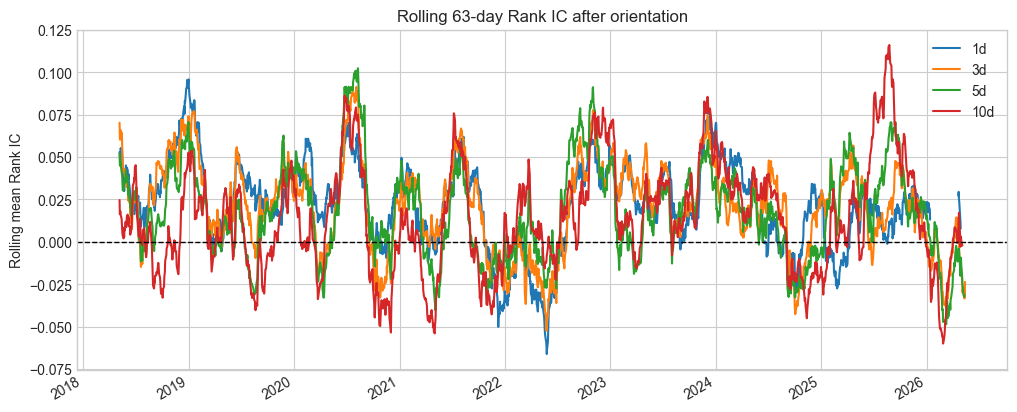

In [5]:
def cross_sectional_corr_by_date(signal: pd.DataFrame, future: pd.DataFrame, method: str = "spearman", min_names: int = 10) -> pd.Series:
    rows = []
    for date in signal.index.intersection(future.index):
        s = signal.loc[date]
        f = future.loc[date]
        valid = s.notna() & f.notna()
        if valid.sum() < min_names:
            rows.append((date, np.nan))
            continue
        x = s[valid].astype(float)
        y = f[valid].astype(float)
        if method == "spearman":
            x = x.rank()
            y = y.rank()
        rows.append((date, x.corr(y, method="pearson")))
    return pd.Series(dict(rows)).sort_index().rename("rank_ic")


def ic_summary(signal: pd.DataFrame, fwd_by_horizon: dict[int, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    series_by_horizon = {}
    for horizon, fwd in fwd_by_horizon.items():
        rank_ic = cross_sectional_corr_by_date(signal, fwd, method="spearman")
        pearson_ic = cross_sectional_corr_by_date(signal, fwd, method="pearson")
        series_by_horizon[horizon] = rank_ic
        rows.append({
            "horizon_days": horizon,
            "mean_rank_ic": rank_ic.mean(),
            "median_rank_ic": rank_ic.median(),
            "rank_ic_vol": rank_ic.std(),
            "rank_icir": rank_ic.mean() / rank_ic.std() if rank_ic.std() and not pd.isna(rank_ic.std()) else np.nan,
            "positive_rank_ic_rate": rank_ic.gt(0).mean(),
            "mean_pearson_ic": pearson_ic.mean(),
            "observations": rank_ic.notna().sum(),
        })
    return pd.DataFrame(rows).set_index("horizon_days"), series_by_horizon

raw_ic_summary, raw_rank_ic_by_horizon = ic_summary(raw_alpha001, forward_returns)
default_raw_ic = raw_ic_summary.loc[DEFAULT_HORIZON, "mean_rank_ic"]
SIGNAL_DIRECTION = 1 if default_raw_ic >= 0 else -1
orientation_label = "raw" if SIGNAL_DIRECTION == 1 else "inverted"
oriented_alpha001 = SIGNAL_DIRECTION * raw_alpha001
oriented_ic_summary, oriented_rank_ic_by_horizon = ic_summary(oriented_alpha001, forward_returns)

raw_ic_summary.to_csv(ARTIFACT_DIR / "raw_ic_summary.csv")
oriented_ic_summary.to_csv(ARTIFACT_DIR / "oriented_ic_summary.csv")
oriented_alpha001.to_csv(ARTIFACT_DIR / "oriented_alpha001_scores.csv")

print(f"Default horizon: {DEFAULT_HORIZON} trading days")
print(f"Raw mean Rank IC at default horizon: {default_raw_ic:.6f}")
print(f"Selected tradable orientation: {orientation_label}")
print("Interpretation after orientation: higher score = more bullish")
print("Raw IC summary")
display(raw_ic_summary)
print("Oriented IC summary")
display(oriented_ic_summary)

fig, ax = plt.subplots(figsize=(12, 5))
for horizon, series in oriented_rank_ic_by_horizon.items():
    series.rolling(63).mean().plot(ax=ax, label=f"{horizon}d")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Rolling 63-day Rank IC after orientation")
ax.set_ylabel("Rolling mean Rank IC")
ax.legend()
plt.show()

## 5. Bucket Diagnostics

Buckets answer a plain question: after orientation, do the top-ranked names beat the bottom-ranked names? Multi-day bucket returns overlap, so this is a signal diagnostic rather than an executable portfolio P&L.

,horizon_days,top_n,mean_top_return,mean_bottom_return,mean_spread_return,spread_hit_rate,observations
0,1,5,0.000964,0.000592,0.000372,0.532258,2046
1,1,10,0.000986,0.000589,0.000397,0.523716,2045
2,3,5,0.002849,0.001455,0.001394,0.524462,2044
3,3,10,0.002656,0.001702,0.000954,0.541361,2043
4,5,5,0.004981,0.002932,0.002049,0.542605,2042
5,5,10,0.004387,0.003234,0.001153,0.522293,2041
6,10,5,0.008806,0.006362,0.002444,0.527737,2037
7,10,10,0.008114,0.006953,0.001161,0.517682,2036


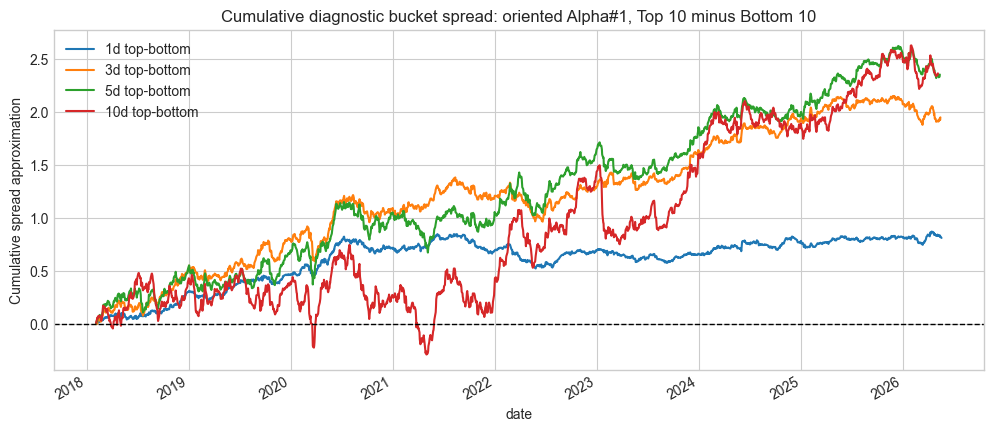

In [6]:
def bucket_returns(signal: pd.DataFrame, future: pd.DataFrame, top_n: int) -> pd.DataFrame:
    rows = []
    for date in signal.index.intersection(future.index):
        scores = signal.loc[date].dropna()
        rets = future.loc[date].dropna()
        common = scores.index.intersection(rets.index)
        if len(common) < top_n * 2:
            continue
        scores = scores[common].sort_values(ascending=False)
        rets = rets[common]
        top_symbols = scores.head(top_n).index
        bottom_symbols = scores.tail(top_n).index
        rows.append({
            "date": date,
            "top_return": rets[top_symbols].mean(),
            "bottom_return": rets[bottom_symbols].mean(),
            "spread_return": rets[top_symbols].mean() - rets[bottom_symbols].mean(),
            "top_symbols": ",".join(top_symbols),
            "bottom_symbols": ",".join(bottom_symbols),
        })
    columns = ["date", "top_return", "bottom_return", "spread_return", "top_symbols", "bottom_symbols"]
    return pd.DataFrame(rows, columns=columns).set_index("date")

bucket_frames = {}
bucket_rows = []
for horizon, fwd in forward_returns.items():
    for top_n in TOP_N_VALUES:
        frame = bucket_returns(oriented_alpha001, fwd, top_n)
        bucket_frames[(horizon, top_n)] = frame
        bucket_rows.append({
            "horizon_days": horizon,
            "top_n": top_n,
            "mean_top_return": frame["top_return"].mean(),
            "mean_bottom_return": frame["bottom_return"].mean(),
            "mean_spread_return": frame["spread_return"].mean(),
            "spread_hit_rate": frame["spread_return"].gt(0).mean(),
            "observations": len(frame),
        })

bucket_summary = pd.DataFrame(bucket_rows)
bucket_summary.to_csv(ARTIFACT_DIR / "bucket_summary.csv", index=False)
display(bucket_summary)

fig, ax = plt.subplots(figsize=(12, 5))
for horizon in FORWARD_HORIZONS:
    frame = bucket_frames[(horizon, 10)]
    if not frame.empty:
        frame["spread_return"].fillna(0).cumsum().plot(ax=ax, label=f"{horizon}d top-bottom")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Cumulative diagnostic bucket spread: oriented Alpha#1, Top 10 minus Bottom 10")
ax.set_ylabel("Cumulative spread approximation")
ax.legend()
plt.show()

## 6. Simple Basket Backtests

This converts the oriented signal into portfolios. The convention here is: compute the signal using data through date `t`, then measure the next session return aligned to `t`. Costs are charged from turnover. Treat this as a daily research simulator; a production backtest should replace it with explicit open/close execution data.

,top_n,long_short,signal_orientation,cost_bps_per_turnover,observations,total_return,cagr,annual_vol,sharpe,sortino,max_drawdown,daily_win_rate,mean_daily_return,avg_daily_turnover
strategy,,,,,,,,,,,,,,
long_only_top5,5,False,inverted,10.000000,2069,-0.762700,-0.160709,0.205922,-0.747121,-1.002386,-0.768346,0.484775,-0.000611,1.562784
long_short_top5,5,True,inverted,10.000000,2069,-0.996761,-0.502521,0.190826,-3.557888,-4.748279,-0.996898,0.400193,-0.002694,3.061769
long_only_top10,10,False,inverted,10.000000,2069,-0.427561,-0.065688,0.188808,-0.264976,-0.349006,-0.522404,0.509425,-0.000199,1.163461
long_short_top10,10,True,inverted,10.000000,2069,-0.983277,-0.392420,0.138303,-3.529948,-4.975291,-0.983548,0.385210,-0.001937,2.328855


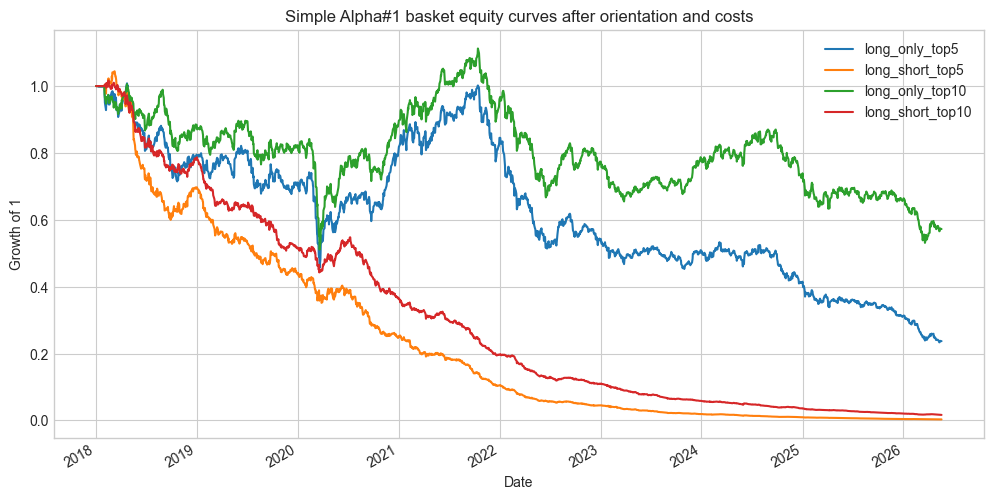

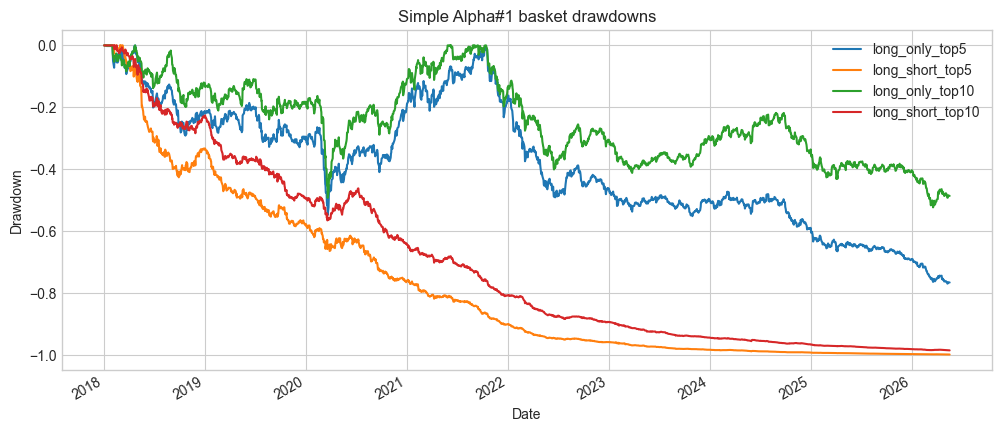

In [7]:
next_session_returns = return_price.pct_change(fill_method=None).shift(-1)


def build_weights(signal: pd.DataFrame, top_n: int, long_short: bool, min_signal: float = -np.inf) -> pd.DataFrame:
    weights = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
    for date in signal.index:
        scores = signal.loc[date].dropna().sort_values(ascending=False)
        scores = scores[scores >= min_signal]
        required = top_n * (2 if long_short else 1)
        if len(scores) < required:
            continue
        top = scores.head(top_n).index
        weights.loc[date, top] = 1.0 / top_n
        if long_short:
            bottom = scores.tail(top_n).index
            weights.loc[date, bottom] = -1.0 / top_n
    return weights


def performance_metrics(returns: pd.Series, turnover: pd.Series | None = None, periods_per_year: int = 252) -> dict:
    r = returns.dropna()
    if r.empty:
        return {}
    equity = (1.0 + r).cumprod()
    years = len(r) / periods_per_year
    total_return = equity.iloc[-1] - 1.0
    cagr = equity.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 and equity.iloc[-1] > 0 else np.nan
    annual_vol = r.std(ddof=0) * math.sqrt(periods_per_year)
    sharpe = (r.mean() * periods_per_year) / annual_vol if annual_vol and annual_vol > 0 else np.nan
    downside = r[r < 0].std(ddof=0) * math.sqrt(periods_per_year)
    sortino = (r.mean() * periods_per_year) / downside if downside and downside > 0 else np.nan
    drawdown = equity / equity.cummax() - 1.0
    return {
        "observations": len(r),
        "total_return": total_return,
        "cagr": cagr,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": drawdown.min(),
        "daily_win_rate": r.gt(0).mean(),
        "mean_daily_return": r.mean(),
        "avg_daily_turnover": turnover.reindex(r.index).mean() if turnover is not None else np.nan,
    }


def backtest_weights(weights: pd.DataFrame, next_returns: pd.DataFrame, cost_bps: float = COST_BPS_PER_TURNOVER) -> dict:
    aligned_returns = next_returns.reindex_like(weights)
    gross = weights.mul(aligned_returns).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    costs = turnover * (cost_bps / 10000.0)
    net = gross - costs
    return {
        "returns": net.dropna(),
        "gross_returns": gross.reindex(net.dropna().index),
        "turnover": turnover.reindex(net.dropna().index).fillna(0),
        "costs": costs.reindex(net.dropna().index).fillna(0),
        "weights": weights,
        "metrics": performance_metrics(net, turnover),
    }

strategy_returns = {}
strategy_turnover = {}
metric_rows = []
for top_n in TOP_N_VALUES:
    for long_short in [False, True]:
        name = f"{'long_short' if long_short else 'long_only'}_top{top_n}"
        weights = build_weights(oriented_alpha001, top_n=top_n, long_short=long_short)
        bt = backtest_weights(weights, next_session_returns)
        strategy_returns[name] = bt["returns"]
        strategy_turnover[name] = bt["turnover"]
        metric_rows.append({
            "strategy": name,
            "top_n": top_n,
            "long_short": long_short,
            "signal_orientation": orientation_label,
            "cost_bps_per_turnover": COST_BPS_PER_TURNOVER,
            **bt["metrics"],
        })

strategy_metrics = pd.DataFrame(metric_rows).set_index("strategy")
strategy_metrics.to_csv(ARTIFACT_DIR / "simple_strategy_metrics.csv")
display(strategy_metrics)

fig, ax = plt.subplots(figsize=(12, 6))
for name, rets in strategy_returns.items():
    (1 + rets.fillna(0)).cumprod().plot(ax=ax, label=name)
ax.set_title("Simple Alpha#1 basket equity curves after orientation and costs")
ax.set_ylabel("Growth of 1")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for name, rets in strategy_returns.items():
    equity = (1 + rets.fillna(0)).cumprod()
    (equity / equity.cummax() - 1).plot(ax=ax, label=name)
ax.set_title("Simple Alpha#1 basket drawdowns")
ax.set_ylabel("Drawdown")
ax.legend()
plt.show()

## 7. Regimes and Rule Search

Now we ask whether the signal works better with thresholding, fewer holdings, slower rebalancing, or regime gates. The full-sample leaderboard is an exploration tool; the walk-forward section below is the more important test.

In [8]:
def make_regime_frame(index_close: pd.Series) -> pd.DataFrame:
    n = index_close.dropna().copy()
    sma50 = n.rolling(50, min_periods=50).mean()
    sma200 = n.rolling(200, min_periods=200).mean()
    index_ret = n.pct_change(fill_method=None)
    vol20 = index_ret.rolling(20, min_periods=20).std() * math.sqrt(252)
    vol_history = vol20.shift(1)
    vol_q_low = vol_history.rolling(252, min_periods=100).quantile(0.33)
    vol_q_high = vol_history.rolling(252, min_periods=100).quantile(0.67)

    trend = pd.Series("sideways", index=n.index, dtype="object")
    trend[(n > sma50) & (sma50 > sma200)] = "bull"
    trend[(n < sma50) & (sma50 < sma200)] = "bear"
    trend[sma50.isna() | sma200.isna()] = "unknown"

    vol_regime = pd.Series("medium_vol", index=n.index, dtype="object")
    vol_regime[vol20 <= vol_q_low] = "low_vol"
    vol_regime[vol20 >= vol_q_high] = "high_vol"
    vol_regime[vol20.isna() | vol_q_low.isna() | vol_q_high.isna()] = "unknown"

    return pd.DataFrame({
        "nifty_close": n,
        "nifty_ret": index_ret,
        "nifty_sma50": sma50,
        "nifty_sma200": sma200,
        "nifty_vol20_ann": vol20,
        "trend_regime": trend,
        "vol_regime": vol_regime,
    })


def allowed_by_regime(row: pd.Series, regime_filter: str) -> bool:
    if regime_filter == "all":
        return True
    if regime_filter == "nifty_bull_or_sideways":
        return row.get("trend_regime") in {"bull", "sideways"}
    if regime_filter == "nifty_bull_only":
        return row.get("trend_regime") == "bull"
    if regime_filter == "not_high_vol":
        return row.get("vol_regime") != "high_vol"
    if regime_filter == "bull_and_not_high_vol":
        return row.get("trend_regime") == "bull" and row.get("vol_regime") != "high_vol"
    raise ValueError(f"Unknown regime_filter: {regime_filter}")

@dataclass(frozen=True)
class StrategyParams:
    top_n: int
    min_signal: float
    rebalance_every: int
    regime_filter: str
    long_short: bool = False
    cost_bps: float = COST_BPS_PER_TURNOVER


def build_rule_weights(signal: pd.DataFrame, regimes: pd.DataFrame, params: StrategyParams) -> pd.DataFrame:
    weights = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
    last_weights = pd.Series(0.0, index=signal.columns)
    for i, date in enumerate(signal.index):
        if i % params.rebalance_every != 0:
            weights.loc[date] = last_weights
            continue
        if date not in regimes.index or not allowed_by_regime(regimes.loc[date], params.regime_filter):
            last_weights = pd.Series(0.0, index=signal.columns)
            weights.loc[date] = last_weights
            continue
        scores = signal.loc[date].dropna().sort_values(ascending=False)
        scores = scores[scores >= params.min_signal]
        required = params.top_n * (2 if params.long_short else 1)
        if len(scores) < required:
            last_weights = pd.Series(0.0, index=signal.columns)
            weights.loc[date] = last_weights
            continue
        new_weights = pd.Series(0.0, index=signal.columns)
        top = scores.head(params.top_n).index
        new_weights.loc[top] = 1.0 / params.top_n
        if params.long_short:
            bottom = scores.tail(params.top_n).index
            new_weights.loc[bottom] = -1.0 / params.top_n
        last_weights = new_weights
        weights.loc[date] = last_weights
    return weights


def backtest_rule(signal: pd.DataFrame, next_returns: pd.DataFrame, regimes: pd.DataFrame, params: StrategyParams) -> dict:
    common = signal.index.intersection(next_returns.index).intersection(regimes.index)
    weights = build_rule_weights(signal.loc[common], regimes.loc[common], params)
    return backtest_weights(weights, next_returns.loc[common], cost_bps=params.cost_bps)


def rule_grid() -> list[StrategyParams]:
    rows = []
    for top_n, min_signal, rebalance_every, regime_filter, long_short in itertools.product(
        [5, 10],
        [0.00, 0.10, 0.20, 0.30],
        [1, 3, 5],
        ["all", "nifty_bull_or_sideways", "not_high_vol"],
        [False, True],
    ):
        rows.append(StrategyParams(top_n=top_n, min_signal=min_signal, rebalance_every=rebalance_every, regime_filter=regime_filter, long_short=long_short))
    return rows


def score_metrics(metrics: dict) -> float:
    sharpe = metrics.get("sharpe", np.nan)
    max_dd = abs(metrics.get("max_drawdown", np.nan))
    turnover = metrics.get("avg_daily_turnover", np.nan)
    total_return = metrics.get("total_return", np.nan)
    return (
        pd.Series([sharpe]).fillna(-999).iloc[0]
        + 0.20 * pd.Series([total_return]).replace([np.inf, -np.inf], np.nan).fillna(-999).iloc[0]
        - 1.50 * pd.Series([max_dd]).fillna(1).iloc[0]
        - 0.10 * pd.Series([turnover]).fillna(1).iloc[0]
    )


def evaluate_grid(signal: pd.DataFrame, next_returns: pd.DataFrame, regimes: pd.DataFrame, grid: list[StrategyParams]) -> pd.DataFrame:
    rows = []
    for params in grid:
        bt = backtest_rule(signal, next_returns, regimes, params)
        metrics = bt["metrics"]
        exposure = bt["weights"].abs().sum(axis=1).gt(0).mean()
        rows.append({
            "top_n": params.top_n,
            "min_signal": params.min_signal,
            "rebalance_every": params.rebalance_every,
            "regime_filter": params.regime_filter,
            "long_short": params.long_short,
            "exposure": exposure,
            **metrics,
            "score": score_metrics(metrics),
        })
    return pd.DataFrame(rows)


def params_from_row(row: pd.Series) -> StrategyParams:
    return StrategyParams(
        top_n=int(row["top_n"]),
        min_signal=float(row["min_signal"]),
        rebalance_every=int(row["rebalance_every"]),
        regime_filter=str(row["regime_filter"]),
        long_short=bool(row["long_short"]),
    )

regimes = make_regime_frame(nifty_close)
display(regimes.tail())
display(regimes[["trend_regime", "vol_regime"]].value_counts().to_frame("days"))

GRID = rule_grid()
search_results = evaluate_grid(oriented_alpha001, next_session_returns, regimes, GRID)
leaderboard = search_results.query("observations >= 252 and exposure >= 0.05").sort_values(["score", "sharpe"], ascending=[False, False]).head(25)
search_results.to_csv(ARTIFACT_DIR / "rule_search_results.csv", index=False)
leaderboard.to_csv(ARTIFACT_DIR / "rule_search_leaderboard.csv", index=False)
display(leaderboard)

best_in_sample_params = params_from_row(leaderboard.iloc[0])
best_in_sample_bt = backtest_rule(oriented_alpha001, next_session_returns, regimes, best_in_sample_params)
print("Best full-sample research params:", best_in_sample_params)
display(pd.Series(best_in_sample_bt["metrics"]).to_frame("best_full_sample_research"))

,nifty_close,nifty_ret,nifty_sma50,nifty_sma200,nifty_vol20_ann,trend_regime,vol_regime
Date,,,,,,,
2026-05-13,23412.599609,0.001414,23872.272070,25048.608604,0.146673,bear,high_vol
2026-05-14,23689.599609,0.011831,23836.414062,25042.214600,0.140460,bear,high_vol
2026-05-15,23643.500000,-0.001946,23799.353047,25034.978604,0.140489,bear,high_vol
2026-05-18,23649.949219,0.000273,23768.779023,25027.923848,0.137736,bear,high_vol
2026-05-19,23703.750000,0.002275,23745.540039,25020.343096,0.138216,bear,high_vol


,,days
trend_regime,vol_regime,
bull,low_vol,455
sideways,high_vol,321
bull,medium_vol,269
sideways,medium_vol,254
bull,high_vol,184
sideways,low_vol,181
bear,high_vol,133
unknown,unknown,120
bear,medium_vol,58


,top_n,min_signal,rebalance_every,regime_filter,long_short,exposure,observations,total_return,cagr,annual_vol,sharpe,sortino,max_drawdown,daily_win_rate,mean_daily_return,avg_daily_turnover,score
66,5,0.300000,5,all,False,0.815802,2063,2.040128,0.145477,0.175800,0.860805,1.098067,-0.227513,0.432865,0.000601,0.294813,0.898080
12,5,0.000000,5,all,False,0.987882,2063,2.752982,0.175334,0.207181,0.884126,1.152876,-0.386572,0.526418,0.000727,0.350073,0.819857
16,5,0.000000,5,not_high_vol,False,0.661658,2063,1.340894,0.109483,0.144066,0.793492,0.909337,-0.190056,0.350460,0.000454,0.239263,0.752660
34,5,0.100000,5,not_high_vol,False,0.661658,2063,1.340894,0.109483,0.144066,0.793492,0.909337,-0.190056,0.350460,0.000454,0.239263,0.752660
106,10,0.100000,5,not_high_vol,False,0.649540,2063,1.120267,0.096148,0.126690,0.788199,0.927447,-0.174713,0.344644,0.000396,0.214542,0.728729
88,10,0.000000,5,not_high_vol,False,0.659234,2063,1.124773,0.096433,0.127676,0.785130,0.928789,-0.174713,0.349491,0.000398,0.216481,0.726367
48,5,0.200000,5,all,False,0.953951,2063,2.139148,0.149970,0.195760,0.812161,1.077529,-0.327404,0.505574,0.000631,0.338633,0.715021
30,5,0.100000,5,all,False,0.983034,2063,2.440571,0.162922,0.206330,0.835427,1.088045,-0.386572,0.522055,0.000684,0.348328,0.708851
52,5,0.200000,5,not_high_vol,False,0.649540,2063,1.246784,0.103936,0.143001,0.763266,0.867514,-0.195461,0.343674,0.000433,0.234804,0.695950
70,5,0.300000,5,not_high_vol,False,0.567135,2063,1.110631,0.095539,0.132751,0.753958,0.813052,-0.201521,0.299564,0.000397,0.208628,0.652939


Best full-sample research params: StrategyParams(top_n=5, min_signal=0.3, rebalance_every=5, regime_filter='all', long_short=False, cost_bps=10.0)


,best_full_sample_research
observations,2063.000000
total_return,2.040128
cagr,0.145477
annual_vol,0.175800
sharpe,0.860805
sortino,1.098067
max_drawdown,-0.227513
daily_win_rate,0.432865
mean_daily_return,0.000601
avg_daily_turnover,0.294813


## 8. Walk-Forward Validation

This is the most important performance checkpoint. Each fold chooses signal direction and strategy parameters using only the training window, then scores the selected rule on the later test window.

,fold,train_start,train_end,test_start,test_end,train_raw_mean_ic,chosen_orientation,chosen_top_n,chosen_min_signal,chosen_rebalance_every,chosen_regime_filter,chosen_long_short,test_observations,test_total_return,test_cagr,test_annual_vol,test_sharpe,test_sortino,test_max_drawdown,test_daily_win_rate,test_mean_daily_return,test_avg_daily_turnover
0,1,2018-01-02,2020-01-24,2020-01-27,2020-07-30,-0.024491,inverted,5,0.000000,5,all,False,126,-0.073463,-0.141528,0.376034,-0.213753,-0.241275,-0.361062,0.547619,-0.000319,0.352381
1,2,2018-07-05,2020-07-30,2020-07-31,2021-01-29,-0.026093,inverted,10,0.300000,5,all,False,126,0.134624,0.287371,0.110723,2.337717,2.527973,-0.044363,0.230159,0.001027,0.139683
2,3,2019-01-11,2021-01-29,2021-02-01,2021-08-04,-0.021864,inverted,10,0.300000,5,all,False,126,-0.019188,-0.038009,0.135856,-0.216787,-0.190502,-0.104865,0.333333,-0.000117,0.185714
3,4,2019-07-19,2021-08-04,2021-08-05,2022-02-04,-0.024805,inverted,5,0.000000,5,not_high_vol,False,126,-0.023892,-0.047214,0.173277,-0.192312,-0.260370,-0.125941,0.428571,-0.000132,0.295238
4,5,2020-01-27,2022-02-04,2022-02-07,2022-08-08,-0.013376,inverted,10,0.200000,5,not_high_vol,False,126,0.095655,0.200460,0.116943,1.621257,1.858286,-0.053523,0.222222,0.000752,0.125397
5,6,2020-07-31,2022-08-08,2022-08-10,2023-02-09,-0.006802,inverted,5,0.300000,5,not_high_vol,False,126,-0.008493,-0.016913,0.147760,-0.041368,-0.056979,-0.147157,0.444444,-0.000024,0.320635
6,7,2021-02-01,2023-02-09,2023-02-10,2023-08-16,-0.010857,inverted,10,0.200000,3,nifty_bull_or_sideways,False,126,0.095717,0.200596,0.102116,1.841991,3.073453,-0.042353,0.547619,0.000746,0.492063
7,8,2021-08-05,2023-08-16,2023-08-17,2024-02-20,-0.011473,inverted,10,0.300000,5,nifty_bull_or_sideways,False,126,0.135886,0.290238,0.088257,2.932690,3.260204,-0.017865,0.238095,0.001027,0.123810
8,9,2022-02-07,2024-02-20,2024-02-21,2024-08-28,-0.025396,inverted,5,0.300000,5,nifty_bull_or_sideways,False,126,0.153317,0.330139,0.176353,1.706975,2.201618,-0.081774,0.531746,0.001195,0.326984
9,10,2022-08-10,2024-08-28,2024-08-29,2025-02-25,-0.022227,inverted,10,0.000000,3,all,False,126,-0.098583,-0.187448,0.156512,-1.247476,-2.054546,-0.138862,0.436508,-0.000775,0.506349


Walk-forward out-of-sample metrics


,walk_forward_oos
observations,1512.000000
total_return,0.390950
cagr,0.056538
annual_vol,0.168955
sharpe,0.410811
sortino,0.446715
max_drawdown,-0.361062
daily_win_rate,0.404101
mean_daily_return,0.000275
avg_daily_turnover,NaN


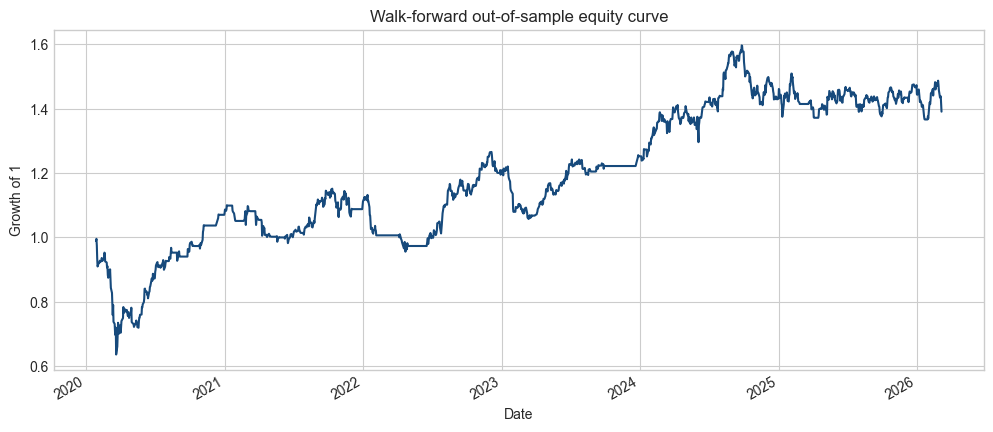

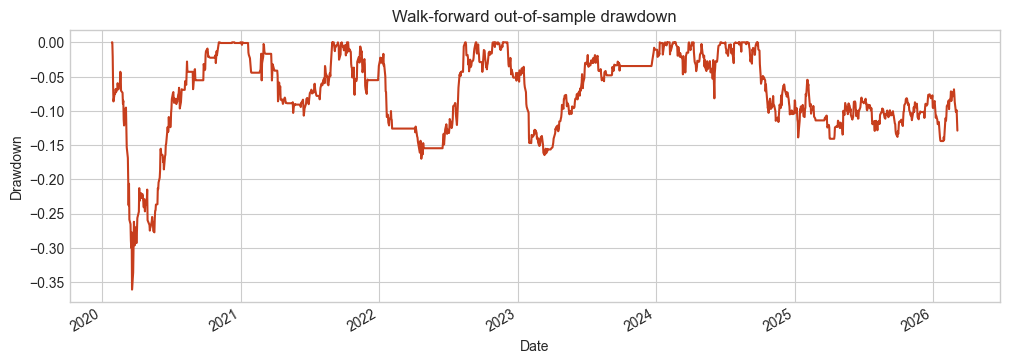

Parameter stability across folds


,fold_count
chosen_orientation,
inverted,12


,fold_count
chosen_top_n,
10,7
5,5


,fold_count
chosen_min_signal,
0.300000,6
0.000000,3
0.200000,2
0.100000,1


,fold_count
chosen_rebalance_every,
5,9
3,3


,fold_count
chosen_regime_filter,
all,5
nifty_bull_or_sideways,4
not_high_vol,3


,fold_count
chosen_long_short,
False,12


In [9]:
def rolling_windows(index: pd.Index, train_days: int = 504, test_days: int = 126, step_days: int = 126):
    idx = pd.Index(index).sort_values()
    start = 0
    while start + train_days + test_days <= len(idx):
        train_idx = idx[start:start + train_days]
        test_idx = idx[start + train_days:start + train_days + test_days]
        yield train_idx, test_idx
        start += step_days


def choose_direction_on_training(raw_signal: pd.DataFrame, train_future: pd.DataFrame) -> tuple[int, float]:
    train_ic = cross_sectional_corr_by_date(raw_signal, train_future, method="spearman")
    mean_ic = train_ic.mean()
    direction = 1 if mean_ic >= 0 else -1
    return direction, mean_ic


def walk_forward_optimize(raw_signal: pd.DataFrame, next_returns: pd.DataFrame, regimes: pd.DataFrame, grid: list[StrategyParams]) -> tuple[pd.DataFrame, pd.Series]:
    common = raw_signal.index.intersection(next_returns.index).intersection(regimes.index)
    fwd_for_orientation = forward_returns[DEFAULT_HORIZON].reindex(index=raw_signal.index, columns=raw_signal.columns)
    rows = []
    oos_returns = []
    for fold, (train_idx, test_idx) in enumerate(rolling_windows(common), start=1):
        direction, train_raw_ic = choose_direction_on_training(raw_signal.loc[train_idx], fwd_for_orientation.loc[train_idx])
        train_signal = direction * raw_signal.loc[train_idx]
        test_signal = direction * raw_signal.loc[test_idx]

        train_results = evaluate_grid(train_signal, next_returns.loc[train_idx], regimes.loc[train_idx], grid)
        train_results = train_results.query("observations >= 126 and exposure >= 0.05")
        if train_results.empty:
            continue
        chosen = train_results.sort_values(["score", "sharpe"], ascending=[False, False]).iloc[0]
        params = params_from_row(chosen)
        test_bt = backtest_rule(test_signal, next_returns.loc[test_idx], regimes.loc[test_idx], params)
        test_returns = test_bt["returns"]
        oos_returns.append(test_returns)
        rows.append({
            "fold": fold,
            "train_start": train_idx[0],
            "train_end": train_idx[-1],
            "test_start": test_idx[0],
            "test_end": test_idx[-1],
            "train_raw_mean_ic": train_raw_ic,
            "chosen_orientation": "raw" if direction == 1 else "inverted",
            "chosen_top_n": params.top_n,
            "chosen_min_signal": params.min_signal,
            "chosen_rebalance_every": params.rebalance_every,
            "chosen_regime_filter": params.regime_filter,
            "chosen_long_short": params.long_short,
            **{f"test_{k}": v for k, v in test_bt["metrics"].items()},
        })
    combined = pd.concat(oos_returns).sort_index() if oos_returns else pd.Series(dtype=float, name="walk_forward_oos_return")
    combined = combined[~combined.index.duplicated(keep="last")].rename("walk_forward_oos_return")
    return pd.DataFrame(rows), combined

WF_GRID = [params for params in GRID if params.top_n in {5, 10} and params.rebalance_every in {1, 3, 5}]
wf_report, wf_returns = walk_forward_optimize(raw_alpha001, next_session_returns, regimes, WF_GRID)
wf_metrics = performance_metrics(wf_returns, pd.Series(index=wf_returns.index, data=np.nan)) if not wf_returns.empty else {}

wf_report.to_csv(ARTIFACT_DIR / "walk_forward_report.csv", index=False)
wf_returns.to_csv(ARTIFACT_DIR / "walk_forward_oos_returns.csv")

display(wf_report)
print("Walk-forward out-of-sample metrics")
display(pd.Series(wf_metrics).to_frame("walk_forward_oos"))

if not wf_returns.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    (1 + wf_returns.fillna(0)).cumprod().plot(ax=ax, color="#174A7C")
    ax.set_title("Walk-forward out-of-sample equity curve")
    ax.set_ylabel("Growth of 1")
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4))
    equity = (1 + wf_returns.fillna(0)).cumprod()
    (equity / equity.cummax() - 1).plot(ax=ax, color="#C73E1D")
    ax.set_title("Walk-forward out-of-sample drawdown")
    ax.set_ylabel("Drawdown")
    plt.show()

if not wf_report.empty:
    print("Parameter stability across folds")
    for col in ["chosen_orientation", "chosen_top_n", "chosen_min_signal", "chosen_rebalance_every", "chosen_regime_filter", "chosen_long_short"]:
        display(wf_report[col].value_counts(dropna=False).to_frame("fold_count"))

## 9. Final Alpha Candidate Table

For the latest signal date, we choose parameters using the most recent training window and produce a candidate table. This is still a research output: it tells us what Alpha#1 would currently prefer under the learned rule, not an instruction to trade without portfolio and risk review.

In [10]:
def stock_level_alpha_report(signal: pd.DataFrame, future_return: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    rows = []
    top_mask = pd.DataFrame(False, index=signal.index, columns=signal.columns)
    bottom_mask = pd.DataFrame(False, index=signal.index, columns=signal.columns)
    for date in signal.index:
        scores = signal.loc[date].dropna().sort_values(ascending=False)
        if len(scores) < top_n * 2:
            continue
        top_mask.loc[date, scores.head(top_n).index] = True
        bottom_mask.loc[date, scores.tail(top_n).index] = True
    for symbol in signal.columns:
        pair = pd.concat([signal[symbol].rename("oriented_alpha"), future_return[symbol].rename("fwd")], axis=1).dropna()
        top_rets = future_return[symbol][top_mask[symbol]].dropna()
        bottom_rets = future_return[symbol][bottom_mask[symbol]].dropna()
        rows.append({
            "symbol": symbol,
            "alpha_fwd_corr": pair["oriented_alpha"].rank().corr(pair["fwd"].rank(), method="pearson") if len(pair) >= 30 else np.nan,
            "top_selected_mean_fwd_return": top_rets.mean(),
            "top_selected_hit_rate": top_rets.gt(0).mean() if len(top_rets) else np.nan,
            "top_selected_count": len(top_rets),
            "bottom_selected_mean_fwd_return": bottom_rets.mean(),
            "bottom_selected_hit_rate": bottom_rets.gt(0).mean() if len(bottom_rets) else np.nan,
            "bottom_selected_count": len(bottom_rets),
        })
    report = pd.DataFrame(rows).set_index("symbol")
    components = pd.DataFrame(index=report.index)
    components["corr"] = report["alpha_fwd_corr"].rank(pct=True)
    components["top_return"] = report["top_selected_mean_fwd_return"].rank(pct=True)
    components["top_hit"] = report["top_selected_hit_rate"].rank(pct=True)
    components["avoid_bottom"] = (-report["bottom_selected_mean_fwd_return"]).rank(pct=True)
    components["sample"] = report["top_selected_count"].rank(pct=True)
    report["alpha001_stock_score"] = (
        0.30 * components["corr"]
        + 0.30 * components["top_return"]
        + 0.20 * components["top_hit"]
        + 0.10 * components["avoid_bottom"]
        + 0.10 * components["sample"]
    )
    return report.sort_values("alpha001_stock_score", ascending=False)


def minmax_score(series: pd.Series) -> pd.Series:
    series = series.astype(float)
    lo, hi = series.min(), series.max()
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(0.5, index=series.index)
    return (series - lo) / (hi - lo)

latest_date = raw_alpha001.dropna(how="all").index[-1]
common = raw_alpha001.index.intersection(next_session_returns.index).intersection(regimes.index)
recent_train_idx = common[common <= latest_date][-504:]
final_direction, final_train_ic = choose_direction_on_training(raw_alpha001.loc[recent_train_idx], forward_returns[DEFAULT_HORIZON].loc[recent_train_idx])
final_signal = final_direction * raw_alpha001
final_orientation_label = "raw" if final_direction == 1 else "inverted"

final_train_results = evaluate_grid(final_signal.loc[recent_train_idx], next_session_returns.loc[recent_train_idx], regimes.loc[recent_train_idx], WF_GRID)
final_train_results = final_train_results.query("observations >= 126 and exposure >= 0.05").sort_values(["score", "sharpe"], ascending=[False, False])
final_params = params_from_row(final_train_results.iloc[0])

stock_ranking = stock_level_alpha_report(final_signal, forward_returns[DEFAULT_HORIZON], top_n=10)
stock_score_scaled = minmax_score(stock_ranking["alpha001_stock_score"])

latest_scores = final_signal.loc[latest_date].dropna().sort_values(ascending=False)
latest_regime = regimes.reindex(final_signal.index).loc[latest_date]
regime_allowed = allowed_by_regime(latest_regime, final_params.regime_filter)
selected_scores = latest_scores[latest_scores >= final_params.min_signal].head(final_params.top_n) if regime_allowed else pd.Series(dtype=float)

recent_ic_series = cross_sectional_corr_by_date(final_signal.loc[recent_train_idx], forward_returns[DEFAULT_HORIZON].loc[recent_train_idx], method="spearman")
recent_ic_score = float(np.clip((recent_ic_series.tail(63).mean() + 0.05) / 0.10, 0, 1)) if len(recent_ic_series) else 0.5

candidate_rows = []
for symbol, score in selected_scores.items():
    raw_score = raw_alpha001.loc[latest_date, symbol]
    confidence = (
        0.35 * recent_ic_score
        + 0.30 * stock_score_scaled.get(symbol, 0.5)
        + 0.20 * float(score > 0)
        + 0.15 * float(regime_allowed)
    )
    candidate_rows.append({
        "date": latest_date,
        "symbol": symbol,
        "alpha": "alpha001",
        "suggested_direction": "long" if not final_params.long_short else "long_leg_candidate",
        "target_weight_equal_weight": 1.0 / len(selected_scores) if len(selected_scores) else np.nan,
        "raw_alpha001_score": raw_score,
        "oriented_signal_score": score,
        "signal_orientation": final_orientation_label,
        "horizon_days": DEFAULT_HORIZON,
        "recent_train_raw_mean_ic": final_train_ic,
        "recent_ic_score": recent_ic_score,
        "stock_score": stock_score_scaled.get(symbol, 0.5),
        "confidence_v0": confidence,
        "trend_regime": latest_regime.get("trend_regime"),
        "vol_regime": latest_regime.get("vol_regime"),
        "regime_filter": final_params.regime_filter,
        "reason": (
            f"passes final Alpha#1 rule: top_n={final_params.top_n}, min_signal={final_params.min_signal}, "
            f"rebalance_every={final_params.rebalance_every}, orientation={final_orientation_label}, "
            f"regime_allowed={regime_allowed}"
        ),
    })

latest_candidates = pd.DataFrame(candidate_rows).sort_values("confidence_v0", ascending=False) if candidate_rows else pd.DataFrame()
stock_ranking.to_csv(ARTIFACT_DIR / "stock_level_alpha_report.csv")
final_train_results.head(25).to_csv(ARTIFACT_DIR / "final_recent_training_leaderboard.csv", index=False)
latest_candidates.to_csv(ARTIFACT_DIR / "latest_alpha001_candidates.csv", index=False)

print("Latest signal date:", latest_date.date())
print("Final recent-training orientation:", final_orientation_label)
print("Final params:", final_params)
print("Current regime:", latest_regime[["trend_regime", "vol_regime"]].to_dict())
print("Regime allowed today:", regime_allowed)
print("Recent training leaderboard")
display(final_train_results.head(10))
print("Top stock compatibility scores")
display(stock_ranking.head(15))
print("Latest Alpha#1 candidate table")
display(latest_candidates)

Latest signal date: 2026-05-19
Final recent-training orientation: inverted
Final params: StrategyParams(top_n=10, min_signal=0.2, rebalance_every=5, regime_filter='all', long_short=False, cost_bps=10.0)
Current regime: {'trend_regime': 'bear', 'vol_regime': 'high_vol'}
Regime allowed today: True
Recent training leaderboard


,top_n,min_signal,rebalance_every,regime_filter,long_short,exposure,observations,total_return,cagr,annual_vol,sharpe,sortino,max_drawdown,daily_win_rate,mean_daily_return,avg_daily_turnover,score
120,10,0.200000,5,all,False,0.811508,504,0.276513,0.129829,0.149637,0.890631,1.252907,-0.157835,0.436508,0.000529,0.268254,0.682356
89,10,0.000000,5,not_high_vol,True,0.466270,504,0.112994,0.054985,0.071155,0.787788,0.970373,-0.087747,0.234127,0.000222,0.314286,0.647337
70,5,0.300000,5,not_high_vol,False,0.525794,504,0.176371,0.084606,0.112868,0.775983,0.937026,-0.101823,0.281746,0.000348,0.190476,0.639475
102,10,0.100000,5,all,False,0.980159,504,0.280780,0.131716,0.165628,0.830034,1.217938,-0.178339,0.527778,0.000546,0.311905,0.587491
106,10,0.100000,5,not_high_vol,False,0.555556,504,0.158388,0.076284,0.113975,0.702049,0.787421,-0.103631,0.291667,0.000318,0.184127,0.559868
87,10,0.000000,5,nifty_bull_or_sideways,True,0.674603,504,0.123922,0.060152,0.092132,0.680089,0.892073,-0.070989,0.349206,0.000249,0.448016,0.553588
138,10,0.300000,5,all,False,0.494048,504,0.159359,0.076736,0.113829,0.706412,0.814456,-0.119702,0.269841,0.000319,0.171825,0.541548
16,5,0.000000,5,not_high_vol,False,0.565476,504,0.167214,0.080377,0.131090,0.655481,0.687236,-0.114705,0.307540,0.000341,0.201587,0.496707
34,5,0.100000,5,not_high_vol,False,0.565476,504,0.167214,0.080377,0.131090,0.655481,0.687236,-0.114705,0.307540,0.000341,0.201587,0.496707
84,10,0.000000,5,all,False,1.000000,504,0.239854,0.113487,0.166317,0.729605,1.083247,-0.204594,0.533730,0.000482,0.316667,0.439018


Top stock compatibility scores


,alpha_fwd_corr,top_selected_mean_fwd_return,top_selected_hit_rate,top_selected_count,bottom_selected_mean_fwd_return,bottom_selected_hit_rate,bottom_selected_count,alpha001_stock_score
symbol,,,,,,,,
RELIANCE,0.082419,0.007197,0.593952,463,0.000744,0.491289,287,0.890625
JSWSTEEL,0.060203,0.007864,0.586498,474,0.003156,0.537367,562,0.850000
APOLLOHOSP,0.073805,0.009809,0.595156,289,0.002669,0.492754,345,0.845833
SBILIFE,0.063966,0.006208,0.586279,481,-0.003008,0.482877,292,0.843750
DRREDDY,0.070766,0.006637,0.601367,439,0.003044,0.515306,588,0.829167
HDFCLIFE,0.048958,0.006750,0.567686,458,0.001807,0.500745,671,0.777083
NESTLEIND,0.044420,0.005386,0.576238,505,0.000145,0.488432,389,0.754167
GRASIM,0.046870,0.006377,0.574742,388,0.001988,0.510448,670,0.713542
POWERGRID,0.051404,0.005693,0.544423,529,0.000735,0.483553,304,0.710417


Latest Alpha#1 candidate table


,date,symbol,alpha,suggested_direction,target_weight_equal_weight,raw_alpha001_score,oriented_signal_score,signal_orientation,horizon_days,recent_train_raw_mean_ic,recent_ic_score,stock_score,confidence_v0,trend_regime,vol_regime,regime_filter,reason
2,2026-05-19,JSWSTEEL,alpha001,long,0.100000,-0.271739,0.271739,inverted,5,-0.009644,0.220754,0.948886,0.711930,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
0,2026-05-19,NESTLEIND,alpha001,long,0.100000,-0.467391,0.467391,inverted,5,-0.009644,0.220754,0.828309,0.675757,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
1,2026-05-19,GRASIM,alpha001,long,0.100000,-0.467391,0.467391,inverted,5,-0.009644,0.220754,0.777195,0.660422,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
9,2026-05-19,TATASTEEL,alpha001,long,0.100000,-0.271739,0.271739,inverted,5,-0.009644,0.220754,0.665793,0.627002,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
8,2026-05-19,NTPC,alpha001,long,0.100000,-0.271739,0.271739,inverted,5,-0.009644,0.220754,0.653997,0.623463,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
7,2026-05-19,EICHERMOT,alpha001,long,0.100000,-0.271739,0.271739,inverted,5,-0.009644,0.220754,0.581913,0.601838,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
4,2026-05-19,M&M,alpha001,long,0.100000,-0.271739,0.271739,inverted,5,-0.009644,0.220754,0.534731,0.587683,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
5,2026-05-19,HINDALCO,alpha001,long,0.100000,-0.271739,0.271739,inverted,5,-0.009644,0.220754,0.508519,0.579820,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
6,2026-05-19,HDFCBANK,alpha001,long,0.100000,-0.271739,0.271739,inverted,5,-0.009644,0.220754,0.471822,0.568810,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."
3,2026-05-19,CIPLA,alpha001,long,0.100000,-0.271739,0.271739,inverted,5,-0.009644,0.220754,0.167759,0.477591,bear,high_vol,all,"passes final Alpha#1 rule: top_n=10, min_signa..."


## Promotion Checklist

Use the notebook outputs in this order:

1. Data checkpoint must show enough usable symbols and no structural OHLC/price failures.
2. Oriented IC should be positive at the chosen horizon and not only from one short period.
3. Bucket spread should be positive after orientation.
4. Simple basket metrics should survive costs.
5. Full-sample rule search is allowed to discover ideas, but promotion depends on walk-forward OOS metrics.
6. Candidate table is an alpha output, not a trade ticket; review liquidity, risk, sector exposure, and execution before use.